# Preparação dos dados

In [1]:
import pandas as pd

# Lê o arquivo
CAMINHO = "C:\\Users\\Nitro\\Desktop\\Deep_Learning\\ge_news.csv"
df = pd.read_csv(CAMINHO)

# Exibe as primeiras linhas
df.head()

,date,time,title,text,link,club
0,10/11/2022,19h55,Convocados do Uruguai para a Copa do Mundo 202...,O técnico Diego Alonso divulgou a lista dos 2...,https://ge.globo.com/futebol/copa-do-mundo/not...,athletico-pr
1,22/12/2017,10h04,Conmebol divulga tabela detalhada da pré e da ...,Argentinos são destaques no caminho dos brasi...,https://globoesporte.globo.com/futebol/liberta...,athletico-pr
2,11/02/2018,08h00,"Com assistência, Demethryus recebe elogios no ...",O meia Demethryus conseguiu aproveitar bem a ...,https://globoesporte.globo.com/pr/futebol/time...,athletico-pr
3,18/12/2020,12h48,Athletico confirma fim de contrato com Welling...,A reportagem do ge já havia adiantado que as ...,https://globoesporte.globo.com/pr/futebol/time...,athletico-pr
4,13/09/2018,22h17,"Alô, cartoleiros! Atlético-PR passa limpo cont...","O atacante Marcelo Cirino, desfalque já nos ú...",https://globoesporte.globo.com/pr/futebol/time...,athletico-pr


In [2]:
# Removendo simultaneamente as colunas de índice 0, 1, 4 (date, time and link)
column_indices = [0, 1, 4]
df.drop([df.columns[i] for i in column_indices], axis = 1, inplace=True)

df.head()

,title,text,club
0,Convocados do Uruguai para a Copa do Mundo 202...,O técnico Diego Alonso divulgou a lista dos 2...,athletico-pr
1,Conmebol divulga tabela detalhada da pré e da ...,Argentinos são destaques no caminho dos brasi...,athletico-pr
2,"Com assistência, Demethryus recebe elogios no ...",O meia Demethryus conseguiu aproveitar bem a ...,athletico-pr
3,Athletico confirma fim de contrato com Welling...,A reportagem do ge já havia adiantado que as ...,athletico-pr
4,"Alô, cartoleiros! Atlético-PR passa limpo cont...","O atacante Marcelo Cirino, desfalque já nos ú...",athletico-pr


In [3]:
# Fundindo colunas 'title' e 'text' para a coluna 'title_and_text'
df['data'] = df['title'] + ' ' + df['text']

df.head()

,title,text,club,data
0,Convocados do Uruguai para a Copa do Mundo 202...,O técnico Diego Alonso divulgou a lista dos 2...,athletico-pr,Convocados do Uruguai para a Copa do Mundo 202...
1,Conmebol divulga tabela detalhada da pré e da ...,Argentinos são destaques no caminho dos brasi...,athletico-pr,Conmebol divulga tabela detalhada da pré e da ...
2,"Com assistência, Demethryus recebe elogios no ...",O meia Demethryus conseguiu aproveitar bem a ...,athletico-pr,"Com assistência, Demethryus recebe elogios no ..."
3,Athletico confirma fim de contrato com Welling...,A reportagem do ge já havia adiantado que as ...,athletico-pr,Athletico confirma fim de contrato com Welling...
4,"Alô, cartoleiros! Atlético-PR passa limpo cont...","O atacante Marcelo Cirino, desfalque já nos ú...",athletico-pr,"Alô, cartoleiros! Atlético-PR passa limpo cont..."


In [4]:
from sklearn.preprocessing import LabelEncoder

# Cria um objeto LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['club'])

In [5]:
df['club'].unique(), df['label'].unique()

(<StringArray>
 [ 'athletico-pr',   'atletico-go',   'atletico-mg',         'bahia',
     'bragantino',      'botafogo',         'ceara',   'corinthians',
       'coritiba',      'flamengo',    'fluminense',     'fortaleza',
          'goias',        'gremio', 'internacional',     'palmeiras',
         'santos',     'sao-paulo',         'sport',         'vasco',
       'cruzeiro']
 Length: 21, dtype: str,
 array([ 0,  1,  2,  3,  5,  4,  6,  7,  8, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20,  9]))

In [6]:
# Removendo as colunas originais, não precisamos mais delas
column_indices = [0, 1, 2]
df.drop([df.columns[i] for i in column_indices], axis = 1, inplace=True)

df.head()

,data,label
0,Convocados do Uruguai para a Copa do Mundo 202...,0
1,Conmebol divulga tabela detalhada da pré e da ...,0
2,"Com assistência, Demethryus recebe elogios no ...",0
3,Athletico confirma fim de contrato com Welling...,0
4,"Alô, cartoleiros! Atlético-PR passa limpo cont...",0


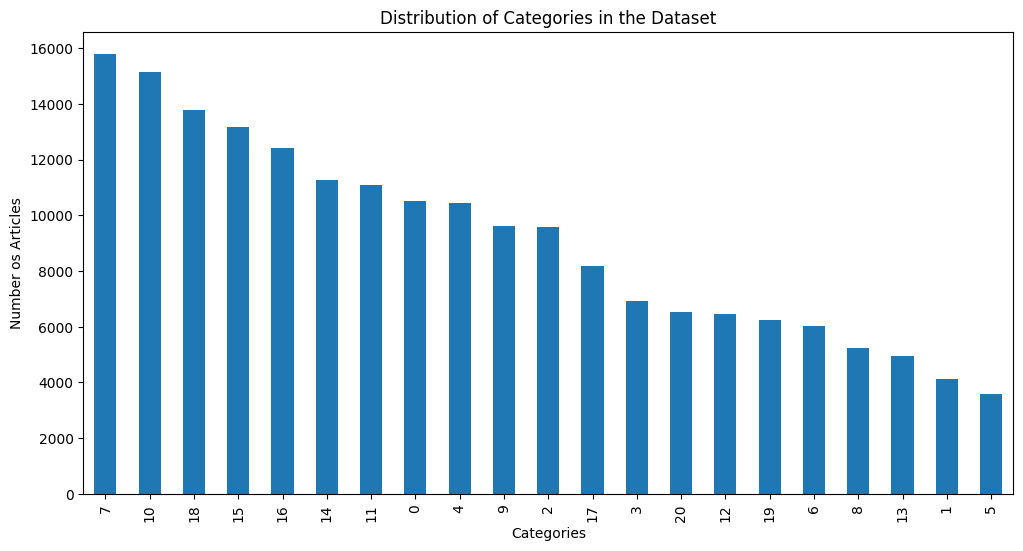

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# COnta quantos elementos (notícias) temos para cada categoria
category_counts = df['label'].value_counts()

# Plota a distribuição das categorias
plt.figure(figsize=(12,6))
category_counts.plot(kind='bar')
plt.xlabel("Categories")
plt.ylabel("Number os Articles")
plt.title("Distribution of Categories in the Dataset")
plt.show()

# Pré-processamento

In [9]:
import string
import spacy
import unicodedata
from tqdm import tqdm
import pandas as pd
import numpy as np

# Habilita o suporte do tqdm para métodos de progressão do pandas (como progress_apply)
# Com isso, é possível ver barras de progresso em operações feitas no Pandas
tqdm.pandas()

# Carrega o modelo de linguagem 'pt_core_news_lg' do spaCy para processamento de texto em português
# Desabilita os componentes 'parser' e 'ner', já que não são necessários para a lematização
spacy_nlp_model = spacy.load('pt_core_news_lg', disable=['parser', 'ner'])

def preprocess_data(df, text_column):
    """
    Realiza o pré-processamento dos dados de texto em um DataFrame do Pandas.
    Remove pontuação, números e palavras comuns (stop words), onverte para minúsculas,
    remove acentos e símbolos diversos, e aplica lematização.
    """

    # Cria uma tabela de tradução que mapeia cada caractere de pontuação do módulo 'string.punctuation'
    # para 'None' (ou seja, remove-os do texto)
    print("Removendo pontuação...")
    translator = str.maketrans('', '', string.punctuation) # Só usamos o terceito parâmetro, que mapeia ocorrências de string.punctuation para None
    df[text_column] = df[text_column].progress_apply(lambda x: x.translate(translator))

    print("Removendo números...")
    translator = str.maketrans('', '', string.digits)
    df[text_column] = df[text_column].progress_apply(lambda x: x.translate(translator))

    print("Removendo acentos e símbolos diversos...")
    def remove_accents_and_symbols(text):
        try:
            # Normaliza a string para a forma NFKD e mantém apenas caracteres que não são diacríticos
            # nem combinam caracteres com diacríticos
            return ''.join(c for c in unicodedata.normalize('NFKD', text) if not unicodedata.combining(c) and unicodedata.category(c) != 'Mn')
        except TypeError:
            # Se nãp for possível normalizar um caractere, retorna uma string vazia
            return ''

    # Aplica a função 'remove_accents_and_symbols' na coluna 'text_column'
    df[text_column] = df[text_column].progress_apply(lambda x: remove_accents_and_symbols(x))

    print("Convertendo para minúsculas...")
    df[text_column] = df[text_column].progress_apply(lambda x: x.lower())

    print("Computando Lematização...")
    def lemmatize_text(doc):
        return [token.lemma_ for token in doc if not token.is_stop]

    n_chunks = 10 # Ajuste esse valor de acordo com o tamanho da base de dados e a memória disponível no sistema
    chunk_indices = np.array_split(np.arange(len(df)), n_chunks)
    chunks = [df.iloc[idx]  for idx in chunk_indices]

    processed_chunks = []
    for i, chunk in enumerate(chunks):
        print(f"Processando segmento {i + 1} de {n_chunks}")
        processed_chunk = chunk.copy() # Cria uma cópia para realizar o processamento

        # Aplica a função 'lemmatize_text' a cada documento processado pelo spaCy (usando 'spacy_nlp_model.pipe') e
        # atribui os resultados (uma lista de palavras lematizadas) à coluna 'text_column' do dataFrame 'processed_chunk'.
        # O tqdm é utilizado para exibir uma barra de progresso durante o processamento dos documentos.
        processed_chunk[text_column] = [lemmatize_text(doc) for doc in tqdm(spacy_nlp_model.pipe(chunk[text_column].astype(str), batch_size=100, disable=['parser', 'ner']), total=len(chunk[text_column]))]

        # Junra as partes em uma lista, para formar o dataframe final
        processed_chunks.append(processed_chunk)

    concatenated_df = pd.concat(processed_chunks) # Concatenar os dataFrames processados
    df[text_column] = concatenated_df[text_column] # Atribuir a coluna 'data' processada de volta ao dataframe original

    print("Remover tokens com espaços vazios...")
    df['data'] = df['data'].progress_apply(lambda x: [token for token in x if token.strip()])


In [ ]:
preprocess_data(df, 'data') # realiza o pré-processamento


In [ ]:
# Salvar em formato pickle
df.to_pickle('ge_df.pkl')

In [ ]:
df['data']

In [ ]:
import pandas as pd

# Carregar dataframe salvo em formato pickle
df = pd.read_pickle('ge_df.pkl')

# Treinando modelo Word2Vec

# Definição

O Word2Vec é um algoritmo de aprendizado de máquina não supervisionado que tem como objetivo aprender representações vetoriais (também conhecidas como incorporações ou embeddings) para palavras em um texto. Essas representações vetoriais capturam informações semânticas e sintáticas sobre as palavras e permitem que elas sejam usadas em tarefas de Processamento de Linguagem Natural (PLN), como análise de sentimentos, agrupamento de documentos, classificação de texto e detecção de similaridade entre palavras.

O Word2Vec foi desenvolvido por Tomas Mikolov e sua equipe no Google e é baseado em duas arquiteturas diferentes: Continuous Bag-of-Words (CBOW) e Skip-Gram. Ambas as arquiteturas usam redes neurais de uma única camada oculta para aprender as representações vetoriais das palavras.

# Tipos de Word2Vec

# Continuous Bag-of-Words (CBOW)

No CBOW, o modelo tenta prever uma palavra com base no contexto em que ela aparece. O contexto é representado como um conjunto de palavras vizinhas (palavras antes e depois da palavra alvo). O objetivo do treinamento é aprender os pesos da rede neural de forma que, dado o contexto, o modelo seja capaz de prever a palavra alvo com a maior probabilidade possível.

# Skip-Gram

No Skip-Gram, a abordagem é invertida em comparação com o CBOW. O modelo tenta prever o contexto (palavras vizinhas) a partir de uma palavra alvo. Durante o treinamento, o modelo aprende os pesos da rede neural de forma que, dada uma palavra alvo, ele possa prever as palavras no contexto com a maior probabilidade possível.

# Exemplos

Vamos supor que temos a seguinte frase: "O gato pulou sobre o cachorro". Com um tamanho de janela de contexto de 2 (uma palavra antes e uma depois), o Word2Vec geraria os seguintes pares de treinamento para a arquitetura CBOW:

([O, pulou], gato)
([gato, sobre], pulou)
([pulou, o], sobre)
([sobre, cachorro], o)
E para a arquitetura Skip-Gram:

(gato, O)
(gato, pulou)
(pulou, gato)
(pulou, sobre)
(sobre, pulou)
(sobre, o)
Ao treinar o modelo Word2Vec nessas arquiteturas, obtemos representações vetoriais das palavras que preservam a semântica e a sintaxe. Por exemplo, palavras semanticamente semelhantes, como "gato" e "cachorro", terão representações vetoriais próximas, no espaço vetorial.